<center><h1><b>Final: GNN with LSTM</b></h1></center>

In [4]:
!pip install torch_geometric torch_scatter torch_sparse torch_cluster torch_spline_conv \
  -f https://data.pyg.org/whl/torch-2.4.1+cpu.html

Looking in links: https://data.pyg.org/whl/torch-2.4.1+cpu.html
     ---------------------------------------- 0.0/801.0 kB ? eta -:--:--
     ---------------------------------------- 0.0/801.0 kB ? eta -:--:--
     ---------------------------------------- 0.0/801.0 kB ? eta -:--:--
     ------------- -------------------------- 262.1/801.0 kB ? eta -:--:--
     ------------------------ ------------- 524.3/801.0 kB 1.0 MB/s eta 0:00:01
     ---------------------------------------- 801.0/801.0 kB 1.8 MB/s  0:00:00
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---------------------------------------- 1.1/1.1 MB 13.9 MB/s  0:00:00

   ------ ---------------------------------  2/12 [propcache]
   ---------------- -----------------------  5/12 [aiohappyeyeballs]
   ----------------------- ----------------  7/12 [torch_sparse]
   ----------------------- ----------------  7/12 [torch_sparse]
   --------------------------------- ------ 10/12 [aiohttp]
   ---------------

In [112]:
# Import required libraries
import pandas as pd
import numpy as np
import torch
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from torch import nn
from torch.optim import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import math
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
# Load dataset
df = pd.read_csv("Processed Datasets/Crime_Weather_Dataset.csv")

print(df.head())
print("\nColumns:", df.columns)
print("\nNumber of rows:", len(df))

         Date Borough  Burglary  Robbery  Theft  Total_Crime  tempmax  \
0  2019-01-01  Camden         9        3     38           50     11.1   
1  2019-01-02  Camden         3        4     39           46      6.6   
2  2019-01-03  Camden        12        2     42           56      5.6   
3  2019-01-04  Camden        16        7     38           61      5.0   
4  2019-01-05  Camden         8        1     47           56      6.1   

   tempmin  temp  humidity  precip  snow  windspeed  visibility  
0      6.5   8.8      74.1     0.0   0.0       11.0        21.9  
1      5.1   5.8      68.9     0.0   0.0        7.8        16.1  
2      4.0   5.1      66.5     0.0   0.0        5.1        19.9  
3      2.5   3.6      70.1     0.0   0.0        7.6         8.5  
4      4.0   5.1      74.0     0.0   0.0        8.9        11.2  

Columns: Index(['Date', 'Borough', 'Burglary', 'Robbery', 'Theft', 'Total_Crime',
       'tempmax', 'tempmin', 'temp', 'humidity', 'precip', 'snow', 'windspeed',
  

In [66]:
# Make sure Date column is datetime
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Split dates exactly as you wanted
train_end = "2020-02-29"
test_start = "2020-06-01"
test_end = "2020-06-28"

train_df = df[df["Date"] <= train_end]
val_df = df[(df["Date"] > train_end) & (df["Date"] < test_start)]
test_df = df[(df["Date"] >= test_start) & (df["Date"] <= test_end)]

print(f"Train size: {len(train_df)}")
print(f"Val size:   {len(val_df)}")
print(f"Test size:  {len(test_df)}")

Train size: 5525
Val size:   1196
Test size:  364


In [67]:
expected_boroughs = [
    "Camden",
    "City of London",
    "Greenwich",
    "Hackney",
    "Hammersmith and Fulham",
    "Islington",
    "Kensington and Chelsea",
    "Lambeth",
    "Lewisham",
    "Southwark",
    "Tower Hamlets",
    "Wandsworth",
    "Westminster",
]

In [68]:
# Border-based undirected adjacency
adjacency_dict = {
    "Camden": ["Islington", "Westminster", "City of London"],
    "City of London": ["Islington", "Hackney", "Tower Hamlets", "Southwark", "Westminster", "Lambeth"],
    "Greenwich": ["Lewisham", "Tower Hamlets"],
    "Hackney": ["Islington", "Tower Hamlets", "City of London"],
    "Hammersmith and Fulham": ["Kensington and Chelsea", "Wandsworth"],
    "Islington": ["Camden", "Hackney", "City of London"],
    "Kensington and Chelsea": ["Hammersmith and Fulham", "Westminster", "Wandsworth"],
    "Lambeth": ["Wandsworth", "Southwark", "Westminster"],
    "Lewisham": ["Greenwich", "Southwark", "Tower Hamlets"],
    "Southwark": ["Lambeth", "Lewisham", "Tower Hamlets", "City of London", "Westminster"],
    "Tower Hamlets": ["Hackney", "City of London", "Southwark", "Greenwich"],
    "Wandsworth": ["Lambeth", "Hammersmith and Fulham", "Westminster"],
    "Westminster": ["Camden", "Kensington and Chelsea", "Lambeth", "Southwark", "City of London"],
}

In [69]:
# Get boroughs actually present in the dataframe 
boros_in_data = sorted(df["Borough"].unique().tolist())

# Sanity checks
missing = set(expected_boroughs) - set(boros_in_data)
extra   = set(boros_in_data) - set(expected_boroughs)
if missing or extra:
    print("Name mismatch:")
    if missing: print("  - Missing in data:", missing)
    if extra:   print("  - In data but not expected:", extra)

In [70]:
# Keep ordering consistent with data 
boroughs = boros_in_data
b2i = {b:i for i,b in enumerate(boroughs)}
num_nodes = len(boroughs)

In [71]:
# Build undirected adjacency matrix with self-loops
A = np.zeros((num_nodes, num_nodes), dtype=np.float32)
for src, nbrs in adjacency_dict.items():
    if src not in b2i: 
        continue
    i = b2i[src]
    for dst in nbrs:
        if dst not in b2i:
            continue
        j = b2i[dst]
        A[i, j] = 1.0
        A[j, i] = 1.0  

# self-loops
np.fill_diagonal(A, 1.0)

In [72]:
# Convert to PyG edge_index
src, dst = np.where(A > 0.0)
edge_index = torch.tensor(np.vstack([src, dst]), dtype=torch.long).contiguous()

In [73]:
# Build normalized dense adjacency 
deg = A.sum(axis=1)
D_inv_sqrt = np.diag(1.0 / np.sqrt(np.clip(deg, 1e-8, None)))
A_hat = torch.tensor(D_inv_sqrt @ A @ D_inv_sqrt, dtype=torch.float32)

print(f"Built graph: nodes={num_nodes}, edges={edge_index.shape[1]} (incl. self-loops)")
print("Order of boroughs (row/col indices):")
for i,b in enumerate(boroughs):
    print(f"{i:2d}: {b}")

Built graph: nodes=13, edges=63 (incl. self-loops)
Order of boroughs (row/col indices):
 0: Camden
 1: City of London
 2: Greenwich
 3: Hackney
 4: Hammersmith and Fulham
 5: Islington
 6: Kensington and Chelsea
 7: Lambeth
 8: Lewisham
 9: Southwark
10: Tower Hamlets
11: Wandsworth
12: Westminster


In [74]:
# Compare raw adjacency matrix A and normalized adjacency matrix A_hat

print("Raw adjacency matrix A (with self-loops):")
print(A)

print("\nNormalized adjacency matrix A_hat (for GCN):")
print(A_hat.numpy())

# Show degree of each node to understand the scaling
deg = A.sum(axis=1)
print("\nNode degrees (including self-loops):")
print(deg)

# Show scaling factors
D_inv_sqrt_diag = 1.0 / np.sqrt(np.clip(deg, 1e-8, None))
print("\nDiagonal values of D_inv_sqrt (scaling factors):")
print(D_inv_sqrt_diag)

Raw adjacency matrix A (with self-loops):
[[1. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1.]
 [1. 1. 0. 1. 0. 1. 0. 1. 0. 1. 1. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0.]
 [0. 1. 0. 1. 0. 1. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 1. 0.]
 [1. 1. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 1. 1.]
 [0. 1. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 1. 1. 1. 1. 0. 1.]
 [0. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 1. 1. 0. 0. 0. 1. 1.]
 [1. 1. 0. 0. 0. 0. 1. 1. 0. 1. 0. 1. 1.]]

Normalized adjacency matrix A_hat (for GCN):
[[0.25       0.17677669 0.         0.         0.         0.25
  0.         0.         0.         0.         0.         0.
  0.18898225]
 [0.17677669 0.12499999 0.         0.17677669 0.         0.17677669
  0.         0.15811388 0.         0.14433756 0.14433756 0.
  0.13363063]
 [0.         0.         0.3333333  0.         0.         0.
  0.         0.         0.2

In [75]:
def neighbors_from_A(A, boroughs):
    # Return dict: borough -> sorted list of neighbor names excludes self.
    out = {}
    for i, b in enumerate(boroughs):
        idxs = np.where((A[i] > 0) & (np.arange(len(boroughs)) != i))[0]
        out[b] = sorted(boroughs[j] for j in idxs)
    return out

In [76]:
def neighbors_from_dict(adjacency_dict, boroughs):
    # Normalise the dict to include only boroughs that exist and remove dups.
    out = {}
    bset = set(boroughs)
    for b in boroughs:
        nbrs = adjacency_dict.get(b, [])
        out[b] = sorted([n for n in nbrs if n in bset and n != b])
    return out

In [77]:
# List order and degrees
print("Order of boroughs (row/col indices):")
for i,b in enumerate(boroughs):
    print(f"{i:2d}: {b}")
print("\nDegrees (including self-loops):", A.sum(axis=1).astype(int))

Order of boroughs (row/col indices):
 0: Camden
 1: City of London
 2: Greenwich
 3: Hackney
 4: Hammersmith and Fulham
 5: Islington
 6: Kensington and Chelsea
 7: Lambeth
 8: Lewisham
 9: Southwark
10: Tower Hamlets
11: Wandsworth
12: Westminster

Degrees (including self-loops): [4 8 3 4 3 4 4 5 4 6 6 5 7]


In [78]:
# Show neighbor lists from A and from your dict side-by-side
nbrs_A    = neighbors_from_A(A, boroughs)
nbrs_dict = neighbors_from_dict(adjacency_dict, boroughs)

rows = []
for b in boroughs:
    rows.append({
        "Borough": b,
        "Neighbors_from_A": ", ".join(nbrs_A[b]),
        "Neighbors_from_dict": ", ".join(nbrs_dict[b]),
        "Match?": "YES" if set(nbrs_A[b]) == set(nbrs_dict[b]) else "NO"
    })
compare_df = pd.DataFrame(rows)
compare_df

,Borough,Neighbors_from_A,Neighbors_from_dict,Match?
0,Camden,"City of London, Islington, Westminster","City of London, Islington, Westminster",YES
1,City of London,"Camden, Hackney, Islington, Lambeth, Southwark...","Hackney, Islington, Lambeth, Southwark, Tower ...",NO
2,Greenwich,"Lewisham, Tower Hamlets","Lewisham, Tower Hamlets",YES
3,Hackney,"City of London, Islington, Tower Hamlets","City of London, Islington, Tower Hamlets",YES
4,Hammersmith and Fulham,"Kensington and Chelsea, Wandsworth","Kensington and Chelsea, Wandsworth",YES
5,Islington,"Camden, City of London, Hackney","Camden, City of London, Hackney",YES
6,Kensington and Chelsea,"Hammersmith and Fulham, Wandsworth, Westminster","Hammersmith and Fulham, Wandsworth, Westminster",YES
7,Lambeth,"City of London, Southwark, Wandsworth, Westmin...","Southwark, Wandsworth, Westminster",NO
8,Lewisham,"Greenwich, Southwark, Tower Hamlets","Greenwich, Southwark, Tower Hamlets",YES
9,Southwark,"City of London, Lambeth, Lewisham, Tower Hamle...","City of London, Lambeth, Lewisham, Tower Hamle...",YES


In [79]:
def add_edge(adjacency_dict, u, v):
    adjacency_dict.setdefault(u, [])
    if v not in adjacency_dict[u]:
        adjacency_dict[u].append(v)

In [80]:
def normalise_A(A):
    deg = A.sum(axis=1)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(np.clip(deg, 1e-8, None)))
    return D_inv_sqrt @ A @ D_inv_sqrt

In [81]:
def rebuild_A(boroughs, adjacency_dict):
    b2i = {b:i for i,b in enumerate(boroughs)}
    A = np.zeros((len(boroughs), len(boroughs)), dtype=np.float32)
    for src, nbrs in adjacency_dict.items():
        if src not in b2i: 
            continue
        i = b2i[src]
        for dst in nbrs:
            if dst not in b2i or dst == src:
                continue
            j = b2i[dst]
            A[i, j] = 1.0
            A[j, i] = 1.0  
    np.fill_diagonal(A, 1.0)  
    return A

In [82]:
# City of London missing Camden in dict
add_edge(adjacency_dict, "City of London", "Camden")

# Lambeth missing City of London
add_edge(adjacency_dict, "Lambeth", "City of London")

# Tower Hamlets mismatch with Lewisham
add_edge(adjacency_dict, "Tower Hamlets", "Lewisham")

# Wandsworth mismatch with Westminster
add_edge(adjacency_dict, "Wandsworth", "Westminster")

# Westminster mismatch with Wandsworth
add_edge(adjacency_dict, "Westminster", "Wandsworth")

In [83]:
A = rebuild_A(boroughs, adjacency_dict)
A_hat = torch.tensor(normalise_A(A), dtype=torch.float32)

compare_df = pd.DataFrame([
    {
        "Borough": b,
        "Neighbors_from_A": ", ".join(neighbors_from_A(A, boroughs)[b]),
        "Neighbors_from_dict": ", ".join(neighbors_from_dict(adjacency_dict, boroughs)[b]),
        "Match?": "YES" if set(neighbors_from_A(A, boroughs)[b]) == set(neighbors_from_dict(adjacency_dict, boroughs)[b]) else "NO"
    }
    for b in boroughs
])

compare_df

,Borough,Neighbors_from_A,Neighbors_from_dict,Match?
0,Camden,"City of London, Islington, Westminster","City of London, Islington, Westminster",YES
1,City of London,"Camden, Hackney, Islington, Lambeth, Southwark...","Camden, Hackney, Islington, Lambeth, Southwark...",YES
2,Greenwich,"Lewisham, Tower Hamlets","Lewisham, Tower Hamlets",YES
3,Hackney,"City of London, Islington, Tower Hamlets","City of London, Islington, Tower Hamlets",YES
4,Hammersmith and Fulham,"Kensington and Chelsea, Wandsworth","Kensington and Chelsea, Wandsworth",YES
5,Islington,"Camden, City of London, Hackney","Camden, City of London, Hackney",YES
6,Kensington and Chelsea,"Hammersmith and Fulham, Wandsworth, Westminster","Hammersmith and Fulham, Wandsworth, Westminster",YES
7,Lambeth,"City of London, Southwark, Wandsworth, Westmin...","City of London, Southwark, Wandsworth, Westmin...",YES
8,Lewisham,"Greenwich, Southwark, Tower Hamlets","Greenwich, Southwark, Tower Hamlets",YES
9,Southwark,"City of London, Lambeth, Lewisham, Tower Hamle...","City of London, Lambeth, Lewisham, Tower Hamle...",YES


In [84]:
# Enforce symmetric undirected edges
def ensure_bidirectional_edge(adj, u, v):
    adj.setdefault(u, [])
    adj.setdefault(v, [])
    if v not in adj[u]:
        adj[u].append(v)
    if u not in adj[v]:
        adj[v].append(u)

def remove_bidirectional_edge(adj, u, v):
    if u in adj and v in adj[u]:
        adj[u].remove(v)
    if v in adj and u in adj[v]:
        adj[v].remove(u)

# Patch Wandsworth to include both neighbors 
ensure_bidirectional_edge(adjacency_dict, "Wandsworth", "Kensington and Chelsea")
ensure_bidirectional_edge(adjacency_dict, "Wandsworth", "Lambeth")

A = rebuild_A(boroughs, adjacency_dict)
A_hat = torch.tensor(normalise_A(A), dtype=torch.float32)

# Re-run the comparison table 
nbrs_A    = neighbors_from_A(A, boroughs)
nbrs_dict = neighbors_from_dict(adjacency_dict, boroughs)

rows = []
for b in boroughs:
    rows.append({
        "Borough": b,
        "Neighbors_from_A": ", ".join(nbrs_A[b]),
        "Neighbors_from_dict": ", ".join(nbrs_dict[b]),
        "Match?": "YES" if set(nbrs_A[b]) == set(nbrs_dict[b]) else "NO"
    })
pd.DataFrame(rows)


,Borough,Neighbors_from_A,Neighbors_from_dict,Match?
0,Camden,"City of London, Islington, Westminster","City of London, Islington, Westminster",YES
1,City of London,"Camden, Hackney, Islington, Lambeth, Southwark...","Camden, Hackney, Islington, Lambeth, Southwark...",YES
2,Greenwich,"Lewisham, Tower Hamlets","Lewisham, Tower Hamlets",YES
3,Hackney,"City of London, Islington, Tower Hamlets","City of London, Islington, Tower Hamlets",YES
4,Hammersmith and Fulham,"Kensington and Chelsea, Wandsworth","Kensington and Chelsea, Wandsworth",YES
5,Islington,"Camden, City of London, Hackney","Camden, City of London, Hackney",YES
6,Kensington and Chelsea,"Hammersmith and Fulham, Wandsworth, Westminster","Hammersmith and Fulham, Wandsworth, Westminster",YES
7,Lambeth,"City of London, Southwark, Wandsworth, Westmin...","City of London, Southwark, Wandsworth, Westmin...",YES
8,Lewisham,"Greenwich, Southwark, Tower Hamlets","Greenwich, Southwark, Tower Hamlets",YES
9,Southwark,"City of London, Lambeth, Lewisham, Tower Hamle...","City of London, Lambeth, Lewisham, Tower Hamle...",YES


In [85]:
# Ensure it's sorted
df = df.sort_values(["Borough", "Date"]).reset_index(drop=True)

# Add day_of_week feature
df["day_of_week"] = df["Date"].dt.dayofweek

In [86]:
# Base features and targets 
base_features = ["temp", "tempmax", "tempmin", "humidity", "precip", "snow", "windspeed", "visibility", "day_of_week"]
targets = ["Burglary", "Robbery", "Theft", "Total_Crime"]

for lag in range(1, 4):  
    for t in targets:    
        col = f"{t}_lag_{lag}"
        if col not in df.columns:
            df[col] = df.groupby("Borough")[t].shift(lag)

# Build the full features list 
features = base_features + [f"{t}_lag_{l}" for t in targets for l in range(1, 4)]

# Drop rows where lags are NaN 
lag_cols = [f"{t}_lag_{l}" for t in targets for l in range(1, 4)]
df = df.dropna(subset=lag_cols).reset_index(drop=True)

# build the Multi-index after modification
df_idx = df.set_index(["Borough", "Date"]).sort_index()

In [87]:
# Split the dataset
train_end = pd.to_datetime("2020-02-29")
val_start = pd.to_datetime("2020-03-01")
val_end   = pd.to_datetime("2020-05-31")
test_start = pd.to_datetime("2020-06-01")
test_end   = pd.to_datetime("2020-06-28")

# use past 7 days to predict next day
lookback = 7 

# Figure out the first usable date for each set based on lookback
first_train_date = df["Date"].min() + pd.Timedelta(days=lookback)
first_val_date   = val_start + pd.Timedelta(days=lookback - 1)

# Create ranges inclusive using only these computed dates
train_targets = pd.date_range(first_train_date, train_end, freq="D")
val_targets   = pd.date_range(first_val_date, val_end, freq="D")
test_targets  = pd.date_range(test_start, test_end, freq="D")

len(train_targets), len(val_targets), len(test_targets)

(415, 86, 28)

In [88]:
# Precompute available date sets per borough 
borough_dates = {b: set(df_idx.loc[b].index) for b in boroughs}

def filter_valid_targets(target_dates, lookback):
    valid = []
    for t in target_dates:
        win = pd.date_range(t - pd.Timedelta(days=lookback), periods=lookback, freq="D")
        # Keep only if every borough has the full lookback window
        if all(win.isin(borough_dates[b]).all() for b in boroughs):
            valid.append(t)
    return valid

In [89]:
train_targets_valid = filter_valid_targets(train_targets, lookback)
val_targets_valid   = filter_valid_targets(val_targets, lookback)
test_targets_valid  = filter_valid_targets(test_targets, lookback)

print(f"#targets  train={len(train_targets_valid)}  val={len(val_targets_valid)}  test={len(test_targets_valid)}")

#targets  train=415  val=86  test=28


In [90]:
def build_sequences(target_dates, lookback, features, targets):
    X_s, Y_s = [], []
    for t in target_dates:
        win = pd.date_range(t - pd.Timedelta(days=lookback), periods=lookback, freq="D")
        X_nodes, Y_nodes = [], []
        for b in boroughs:
            X_nodes.append(df_idx.loc[(b, win), features].values)  
            Y_nodes.append(df_idx.loc[(b, t),   targets].values)   
        X_s.append(np.stack(X_nodes, axis=0)) 
        Y_s.append(np.stack(Y_nodes, axis=0))  
    if len(X_s) == 0:
        return (np.zeros((0, num_nodes, lookback, len(features)), dtype=np.float32),
                np.zeros((0, num_nodes, len(targets)), dtype=np.float32))
    return np.stack(X_s, axis=0), np.stack(Y_s, axis=0)

In [91]:
X_train_raw, y_train_raw = build_sequences(train_targets_valid, lookback, features, targets)
X_val_raw,   y_val_raw   = build_sequences(val_targets_valid,   lookback, features, targets)
X_test_raw,  y_test_raw  = build_sequences(test_targets_valid,  lookback, features, targets)

print("Shapes raw:",
      X_train_raw.shape, y_train_raw.shape,
      X_val_raw.shape,   y_val_raw.shape,
      X_test_raw.shape,  y_test_raw.shape)

Shapes raw: (415, 13, 7, 21) (415, 13, 4) (86, 13, 7, 21) (86, 13, 4) (28, 13, 7, 21) (28, 13, 4)


In [92]:
# Fit on train only
X_scaler = MinMaxScaler().fit(X_train_raw.reshape(-1, X_train_raw.shape[-1]))
y_scaler = MinMaxScaler().fit(y_train_raw.reshape(-1, y_train_raw.shape[-1]))

In [93]:
def scale_sequences(X, Y, X_scaler, Y_scaler):
    Xs = X_scaler.transform(X.reshape(-1, X.shape[-1])).reshape(X.shape).astype(np.float32)
    Ys = Y_scaler.transform(Y.reshape(-1, Y.shape[-1])).reshape(Y.shape).astype(np.float32)
    return Xs, Ys

In [94]:
X_train, y_train = scale_sequences(X_train_raw, y_train_raw, X_scaler, y_scaler)
X_val,   y_val   = scale_sequences(X_val_raw,   y_val_raw,   X_scaler, y_scaler)
X_test,  y_test  = scale_sequences(X_test_raw,  y_test_raw,  X_scaler, y_scaler)

In [95]:
device   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_train_t = torch.tensor(X_train, device=device)  
y_train_t = torch.tensor(y_train, device=device)  
X_val_t   = torch.tensor(X_val,   device=device)
y_val_t   = torch.tensor(y_val,   device=device)
X_test_t  = torch.tensor(X_test,  device=device)
y_test_t  = torch.tensor(y_test,  device=device)

X_train_t.shape, y_train_t.shape

(torch.Size([415, 13, 7, 21]), torch.Size([415, 13, 4]))

In [96]:
A_hat_t = A_hat.to(device)

class SimpleGCN(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.lin = nn.Linear(in_dim, out_dim, bias=False)
    def forward(self, X, A_hat):
        XW = self.lin(X)  
        # Message passing via normalised adjacency
        return torch.relu(torch.einsum("ij,bjf->bif", A_hat, XW))

In [97]:
class GNN_LSTM(nn.Module):
    def __init__(self, num_nodes, in_dim, gnn_hidden, lstm_hidden, out_dim, lookback):
        super().__init__()
        self.gcn = SimpleGCN(in_dim, gnn_hidden)
        self.lstm = nn.LSTM(input_size=gnn_hidden, hidden_size=lstm_hidden, batch_first=True)
        self.fc = nn.Linear(lstm_hidden, out_dim)
        self.num_nodes = num_nodes
        self.lookback = lookback

    def forward(self, X_seq, A_hat):
        S, N, L, F = X_seq.shape
        gnn_steps = []
        for t in range(L):
            Xt = X_seq[:, :, t, :]           
            Ht = self.gcn(Xt, A_hat)          
            gnn_steps.append(Ht.unsqueeze(2)) 
        H_seq = torch.cat(gnn_steps, dim=2)    

        SN = S * N
        H_seq = H_seq.reshape(SN, L, -1)
        lstm_out, _ = self.lstm(H_seq)         
        last = lstm_out[:, -1, :]              
        out = self.fc(last)                    
        out = out.reshape(S, N, -1)            
        return out

In [98]:
num_features = len(features)
num_targets = len(targets)

model = GNN_LSTM(
    num_nodes = num_nodes,
    in_dim = num_features,
    gnn_hidden = 32,
    lstm_hidden = 64,
    out_dim = num_targets,
    lookback = lookback
).to(device)

In [99]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

sum(p.numel() for p in model.parameters()) 

26020

In [100]:
epochs = 50
for ep in range(1, epochs+1):
    model.train()
    optimizer.zero_grad()
    pred_tr = model(X_train_t, A_hat_t)
    loss_tr = criterion(pred_tr, y_train_t)
    loss_tr.backward()
    optimizer.step()

    if ep % 5 == 0:
        model.eval()
        with torch.no_grad():
            pred_val = model(X_val_t, A_hat_t)
            loss_val = criterion(pred_val, y_val_t)
        print(f"Epoch {ep:03d} | "
            f"Train RMSE: {math.sqrt(loss_tr.item()):.4f} | "
            f"Val RMSE: {math.sqrt(loss_val.item()):.4f}")

Epoch 005 | Train RMSE: 0.2243 | Val RMSE: 0.1022
Epoch 010 | Train RMSE: 0.1784 | Val RMSE: 0.0831
Epoch 015 | Train RMSE: 0.1420 | Val RMSE: 0.1241
Epoch 020 | Train RMSE: 0.1521 | Val RMSE: 0.1640
Epoch 025 | Train RMSE: 0.1425 | Val RMSE: 0.1317
Epoch 030 | Train RMSE: 0.1408 | Val RMSE: 0.1093
Epoch 035 | Train RMSE: 0.1418 | Val RMSE: 0.1057
Epoch 040 | Train RMSE: 0.1399 | Val RMSE: 0.1121
Epoch 045 | Train RMSE: 0.1388 | Val RMSE: 0.1200
Epoch 050 | Train RMSE: 0.1387 | Val RMSE: 0.1197


In [101]:
model.eval()
with torch.no_grad():
    pred_te_scaled = model(X_test_t, A_hat_t).cpu().numpy()   
    true_te_scaled = y_test_t.cpu().numpy()

In [102]:
# Inverse-scale back to original units
S, N, Tdim = pred_te_scaled.shape
pred_flat = pred_te_scaled.reshape(-1, Tdim)
true_flat = true_te_scaled.reshape(-1, Tdim)
pred_inv  = y_scaler.inverse_transform(pred_flat).reshape(S, N, Tdim)
true_inv  = y_scaler.inverse_transform(true_flat).reshape(S, N, Tdim)

In [103]:
# Metrics per borough × crime
rows = []
for i, b in enumerate(boroughs):
    for j, crime in enumerate(targets):
        y_true = true_inv[:, i, j]
        y_pred = pred_inv[:, i, j]
        rmse = math.sqrt(mean_squared_error(y_true, y_pred))
        mae  = mean_absolute_error(y_true, y_pred)
        rows.append({"Borough": b, "Crime": crime, "RMSE": rmse, "MAE": mae})

results_df = pd.DataFrame(rows)

In [104]:
print("=== GNN+LSTM — Test RMSE per Borough × Crime ===")
display(results_df.sort_values(["Borough","Crime"]).reset_index(drop=True))

=== GNN+LSTM — Test RMSE per Borough × Crime ===


,Borough,Crime,RMSE,MAE
0,Camden,Burglary,3.354443,2.833959
1,Camden,Robbery,1.716209,1.489237
2,Camden,Theft,16.166102,15.089225
3,Camden,Total_Crime,20.742533,19.411821
4,City of London,Burglary,5.253294,4.726534
5,City of London,Robbery,2.714553,2.496848
6,City of London,Theft,24.232849,23.484987
7,City of London,Total_Crime,31.712535,30.881413
8,Greenwich,Burglary,3.343361,2.868052
9,Greenwich,Robbery,1.960080,1.657429


In [105]:
# Optional summaries
print("\n=== Average RMSE by Crime ===")
display(results_df.groupby("Crime")["RMSE"].mean().round(3))


=== Average RMSE by Crime ===


Crime
Burglary        3.724
Robbery         2.221
Theft          19.606
Total_Crime    24.636
Name: RMSE, dtype: float64

In [106]:
print("\n=== Average RMSE by Borough ===")
display(results_df.groupby("Borough")["RMSE"].mean().round(3))


=== Average RMSE by Borough ===


Borough
Camden                    10.495
City of London            15.978
Greenwich                 12.616
Hackney                    8.611
Hammersmith and Fulham    15.623
Islington                 11.389
Kensington and Chelsea    15.995
Lambeth                   11.463
Lewisham                  10.560
Southwark                 11.372
Tower Hamlets             18.856
Wandsworth                11.775
Westminster                8.378
Name: RMSE, dtype: float64

In [107]:
all_predictions = {}
for i, b in enumerate(boroughs):
    all_predictions[b] = {
        "dates": list(pd.to_datetime(test_targets_valid)),  
        "pred":  pred_inv[:, i, :], 
        "true":  true_inv[:, i, :],   
    }

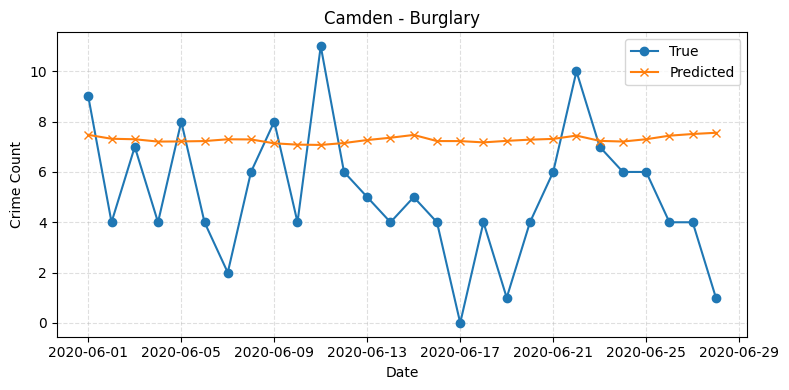

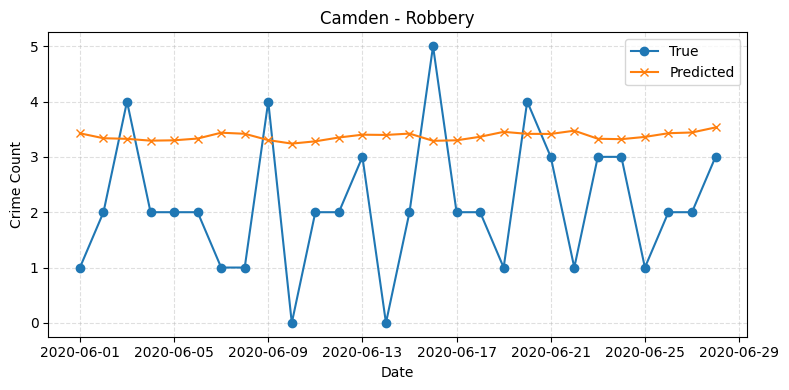

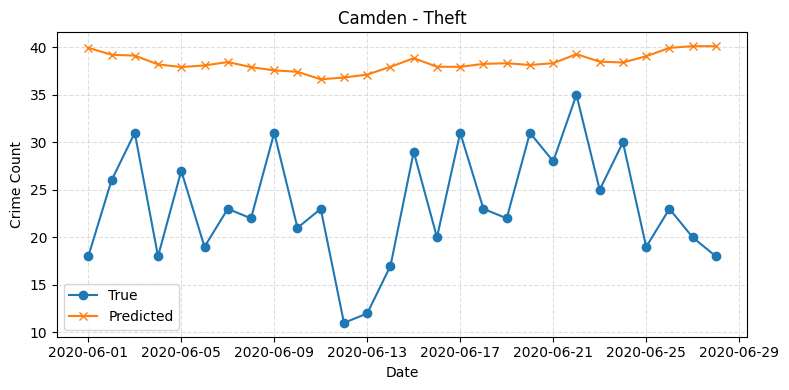

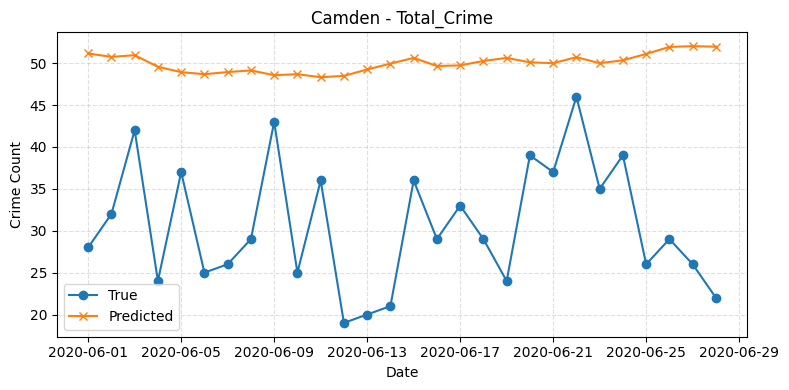

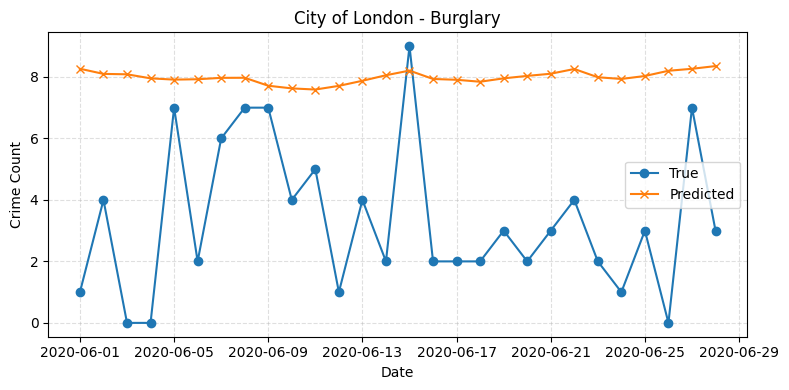

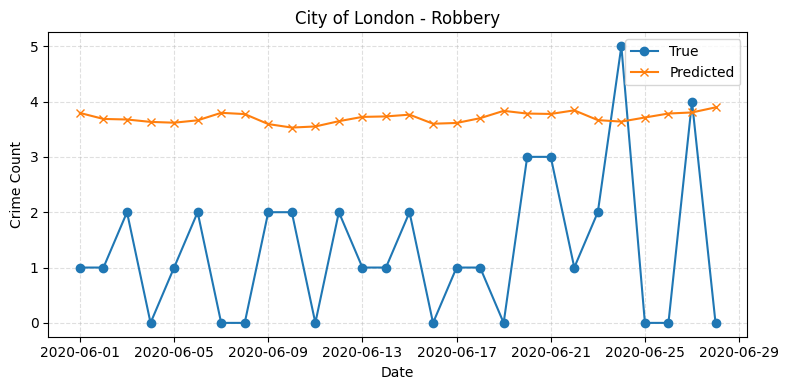

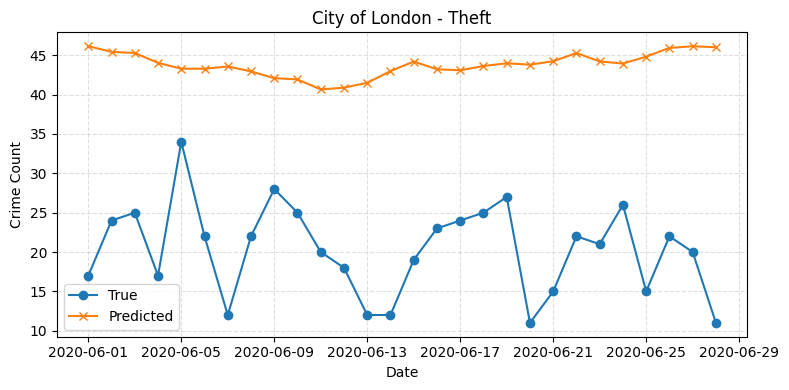

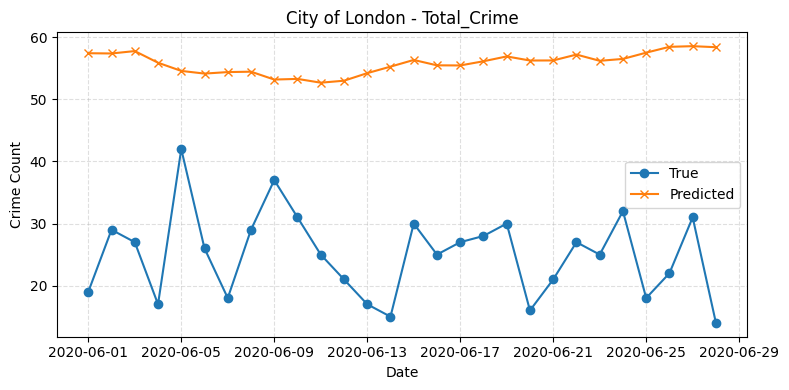

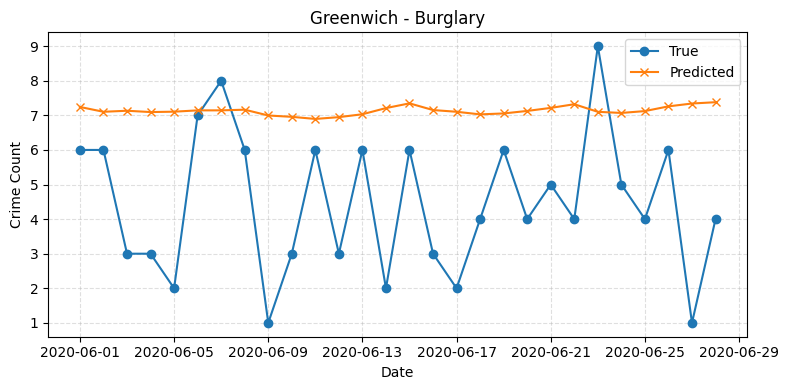

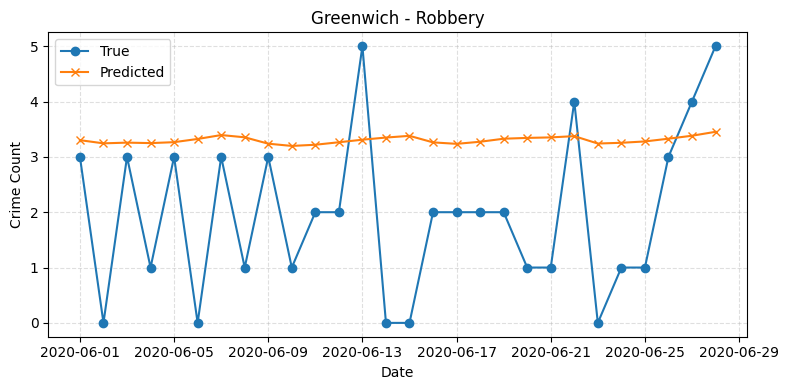

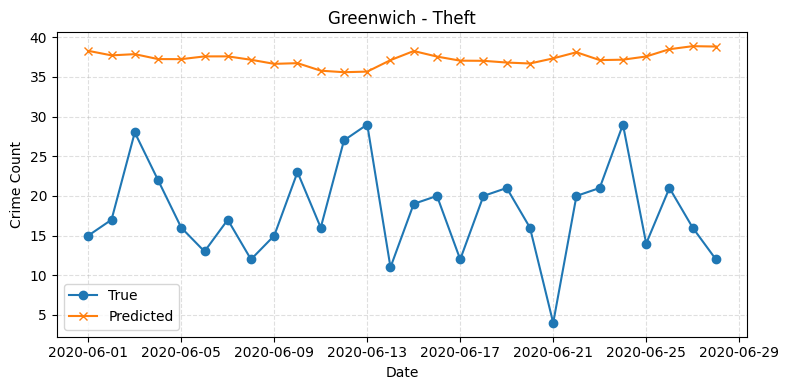

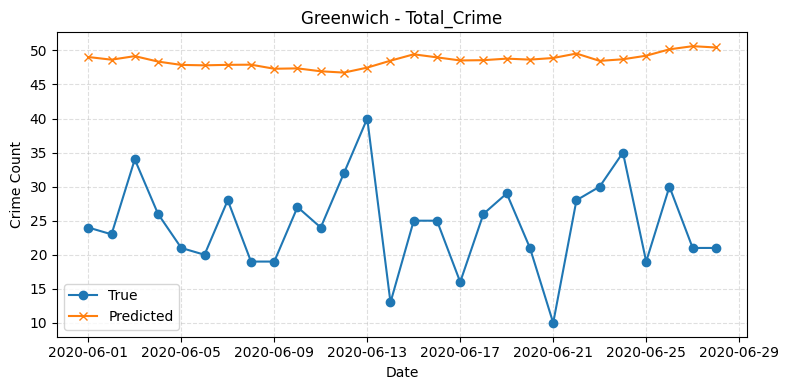

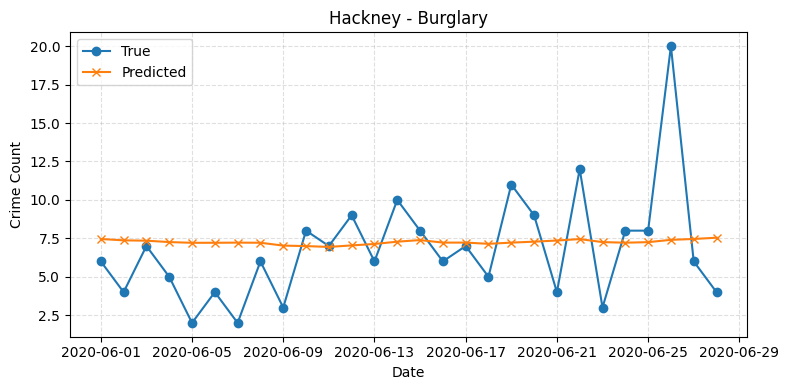

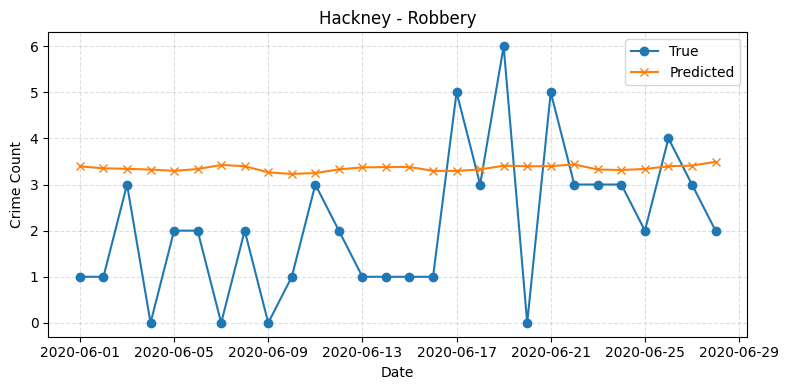

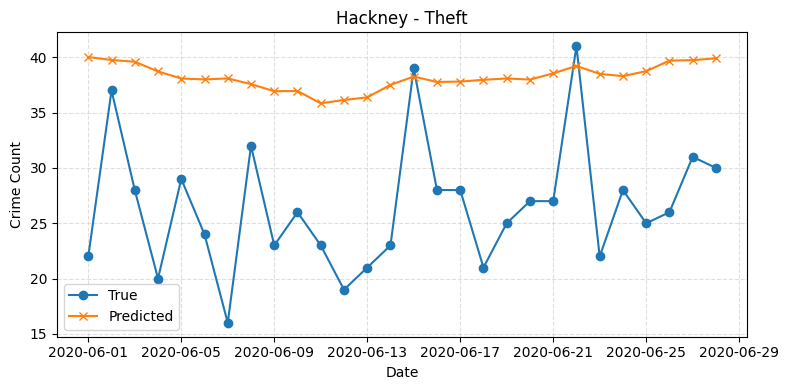

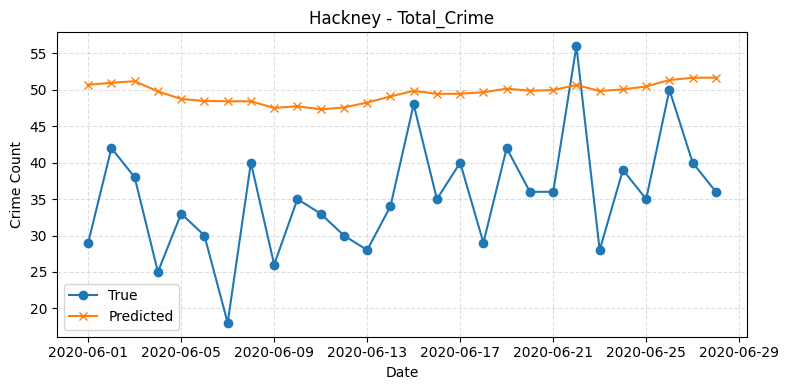

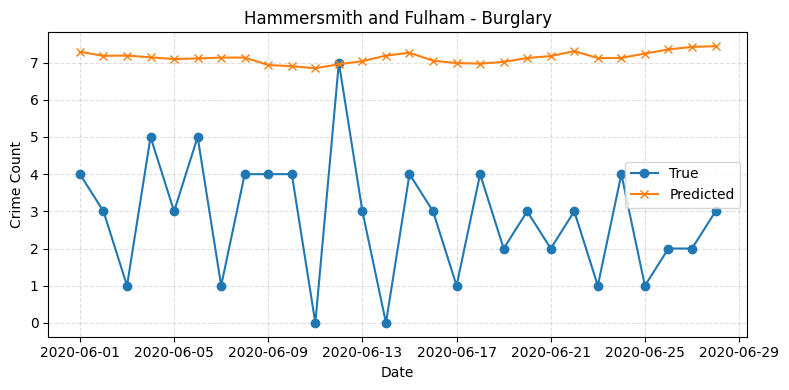

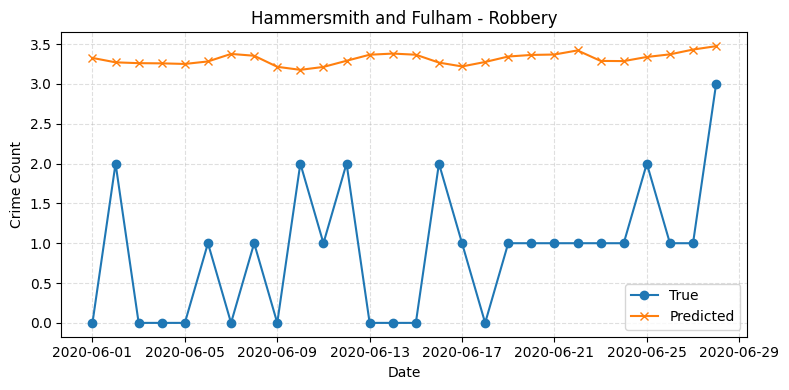

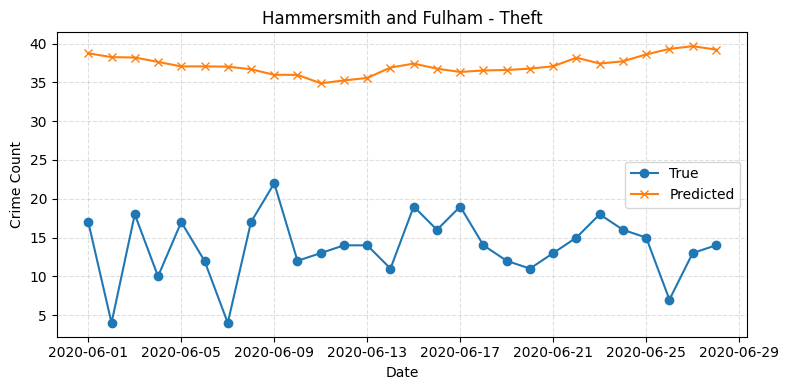

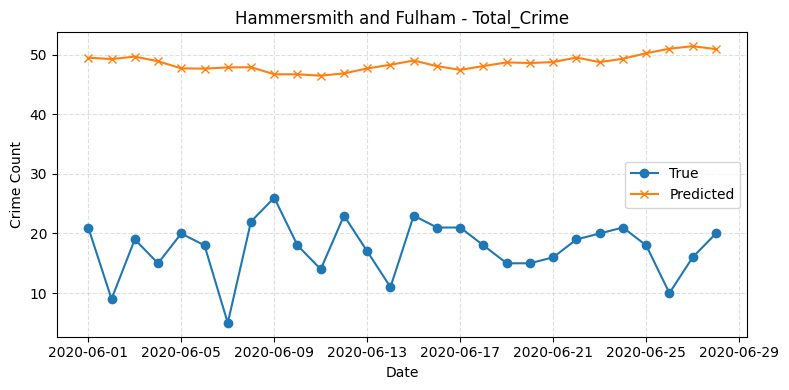

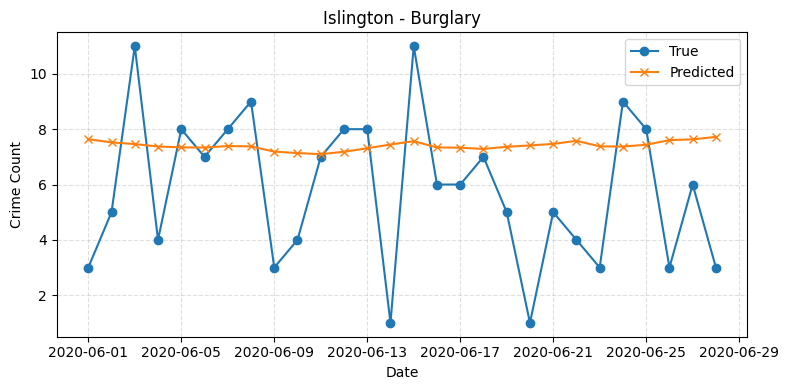

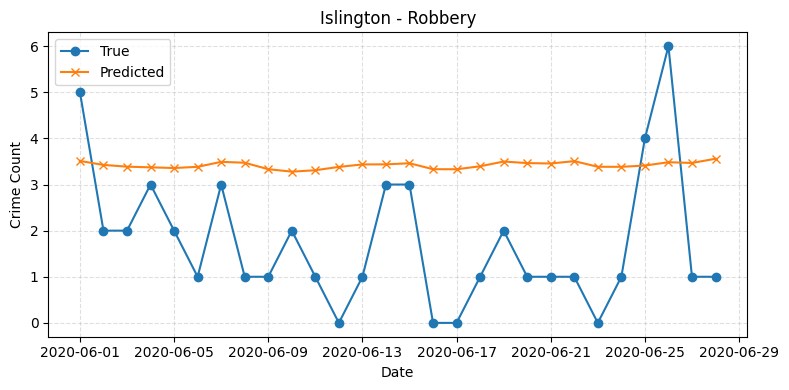

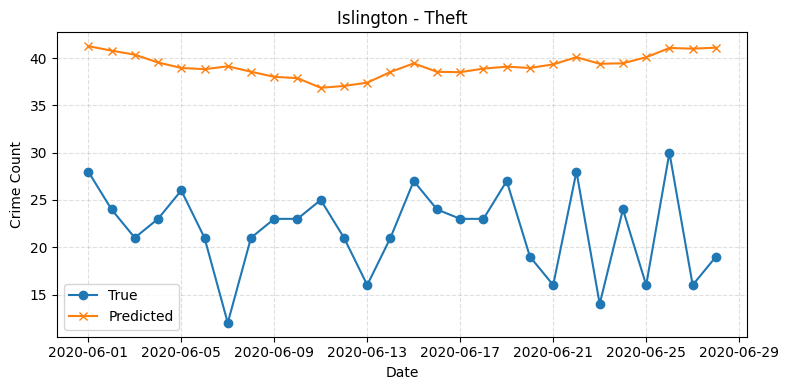

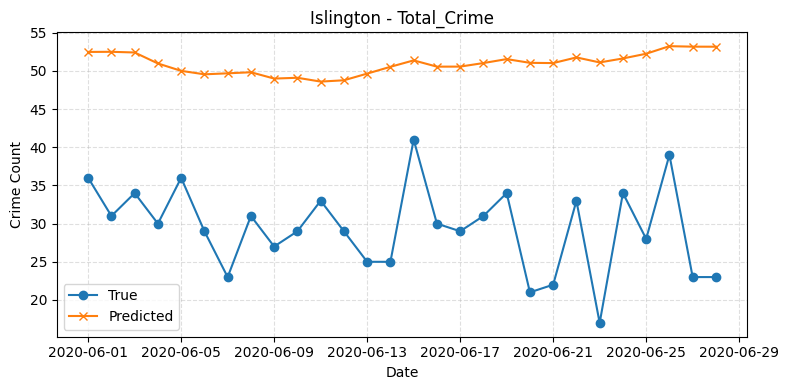

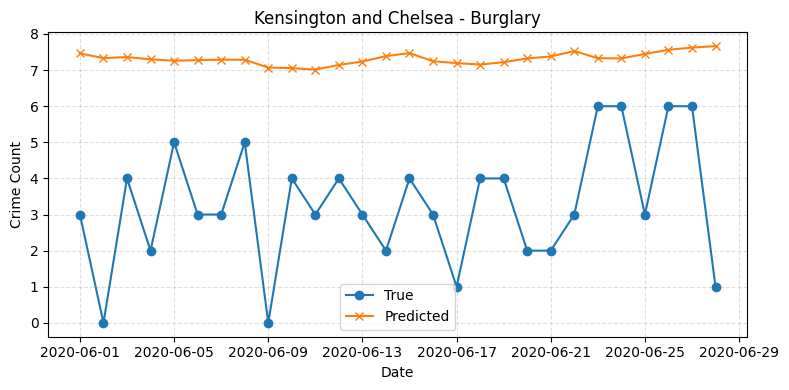

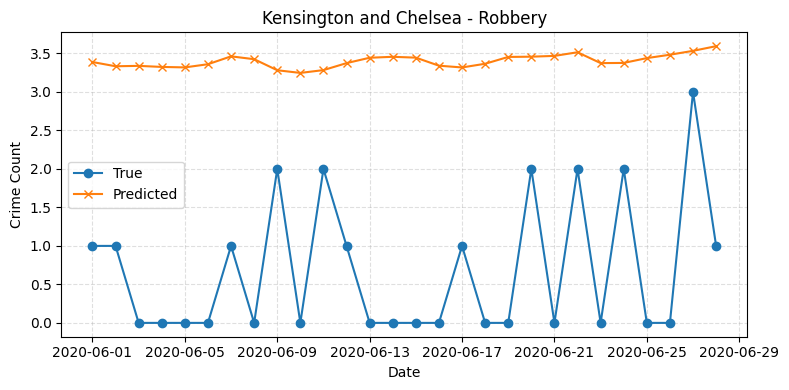

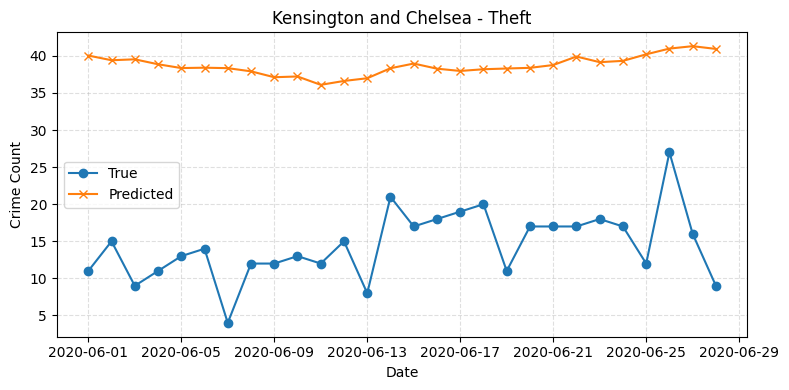

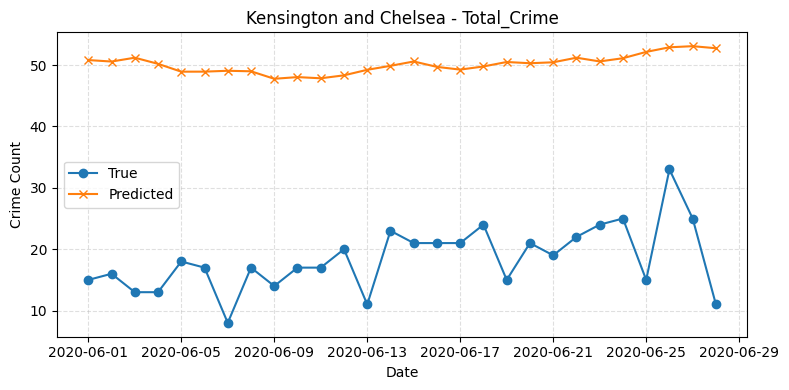

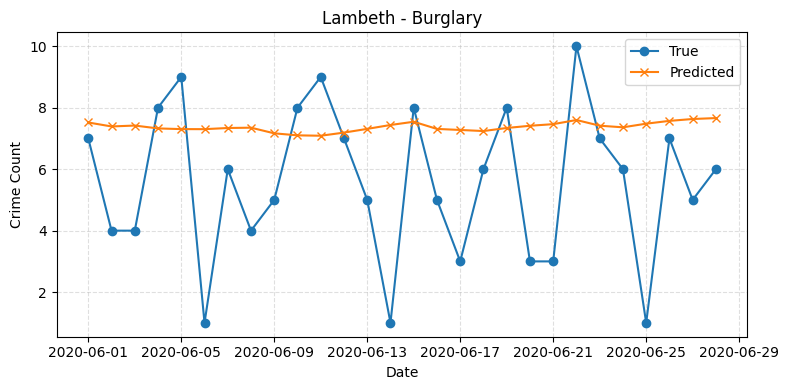

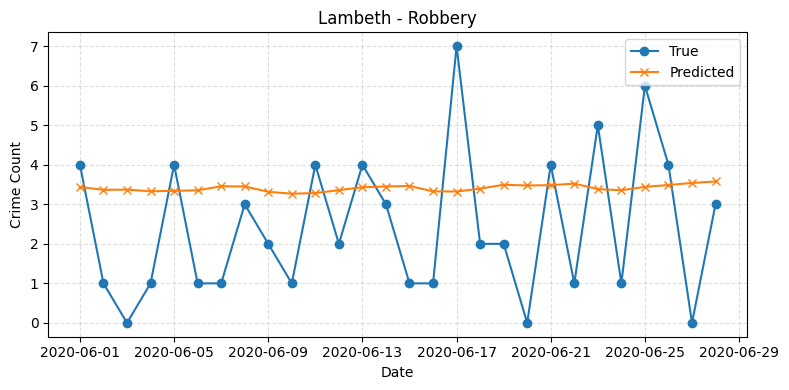

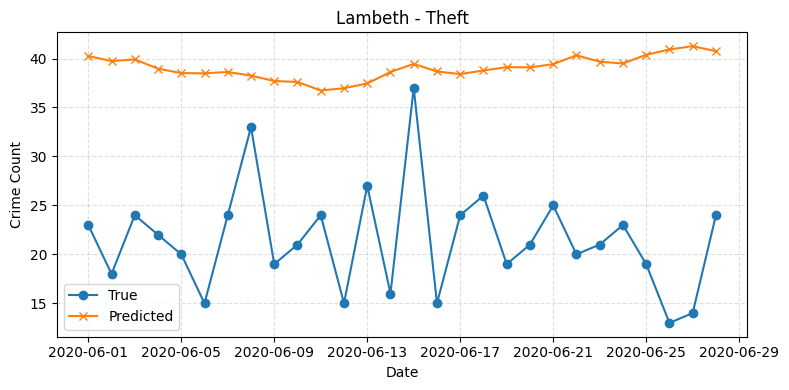

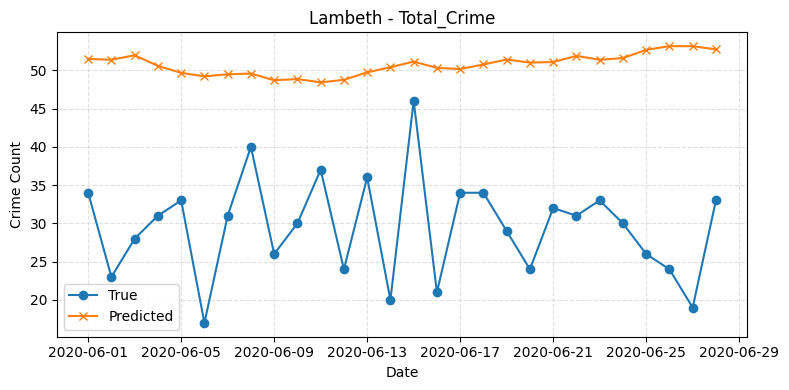

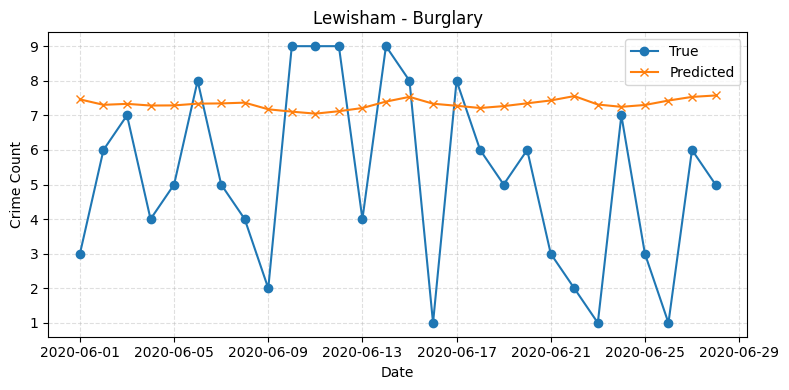

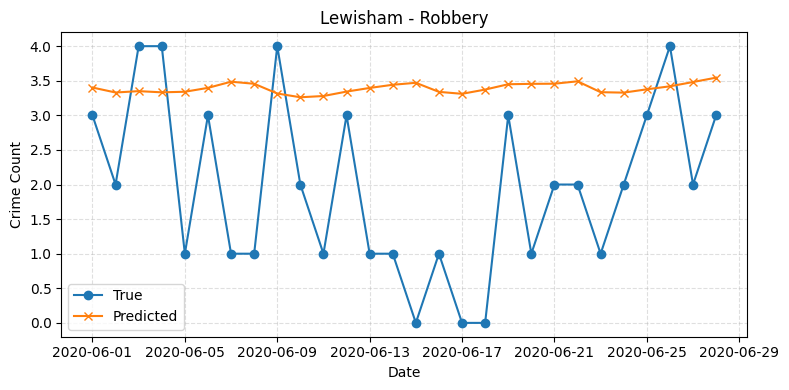

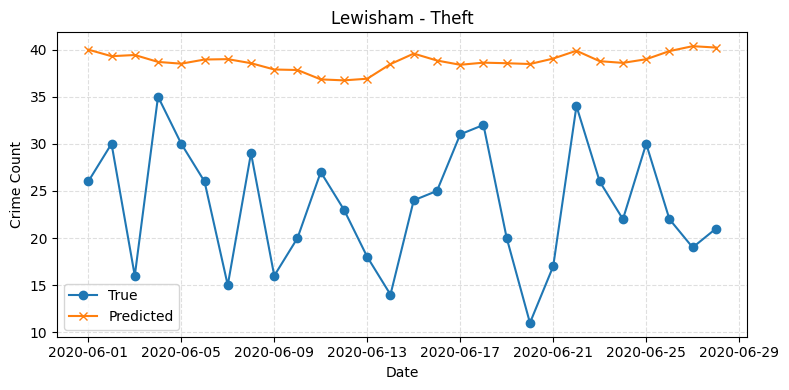

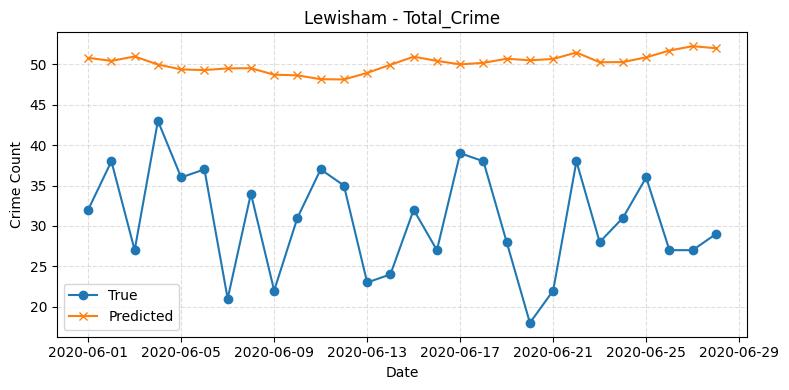

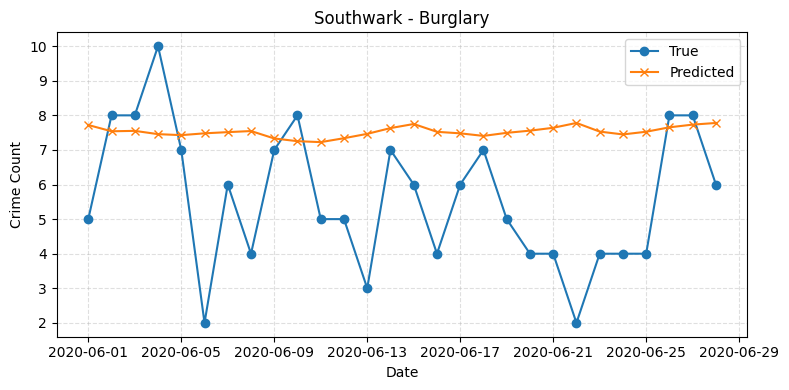

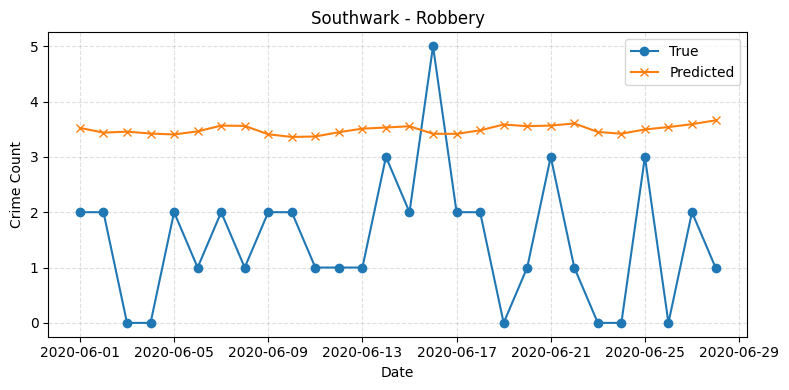

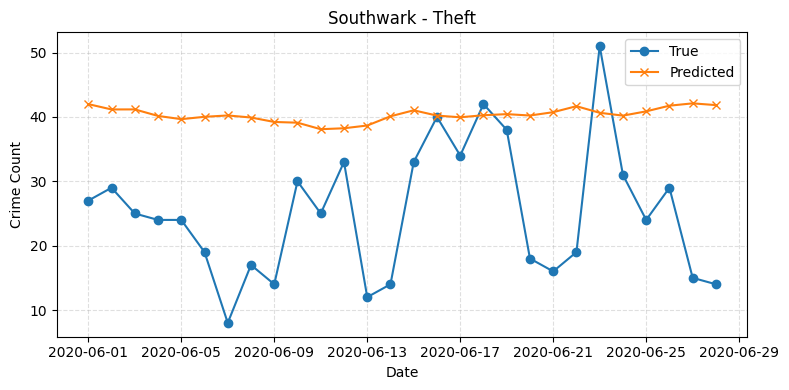

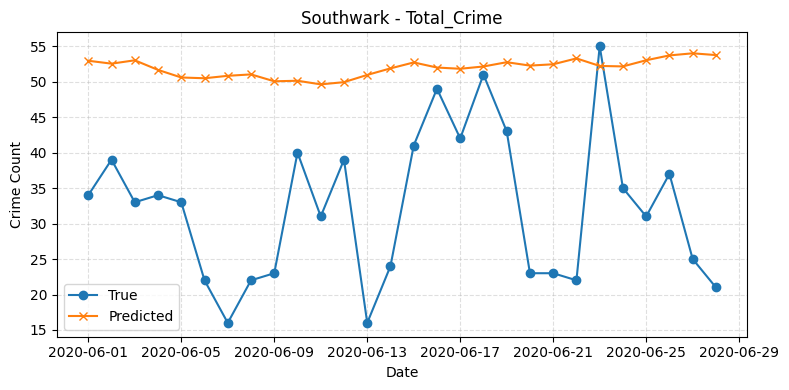

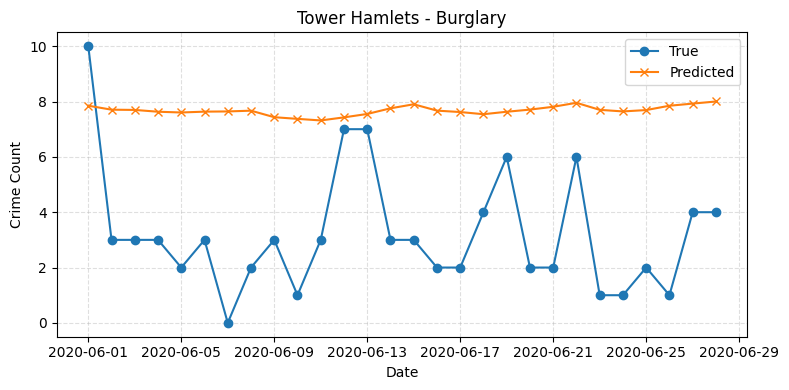

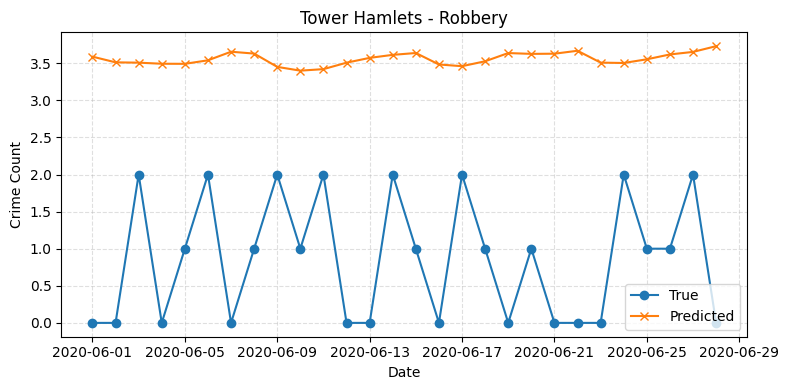

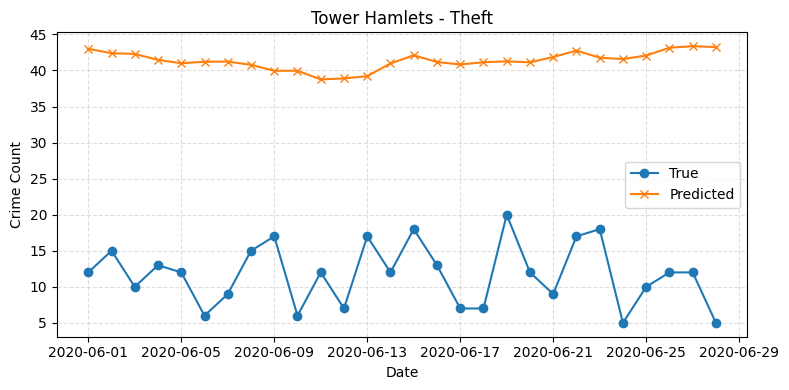

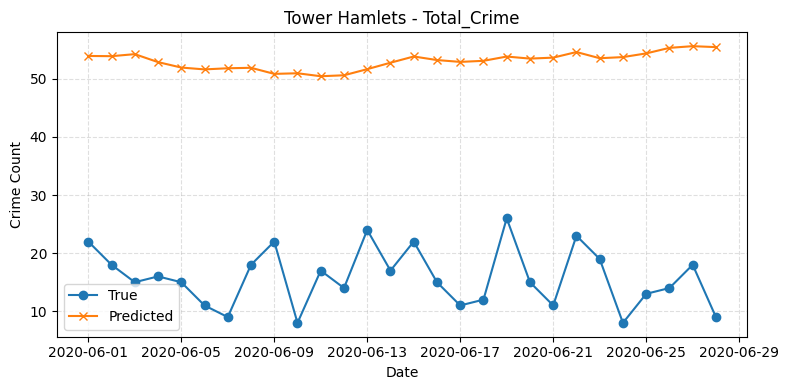

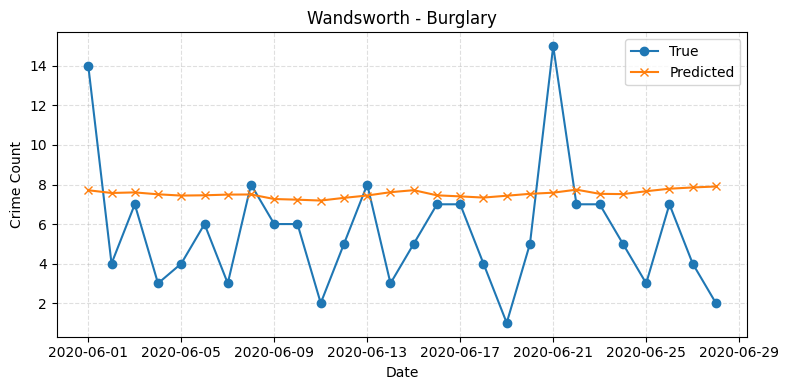

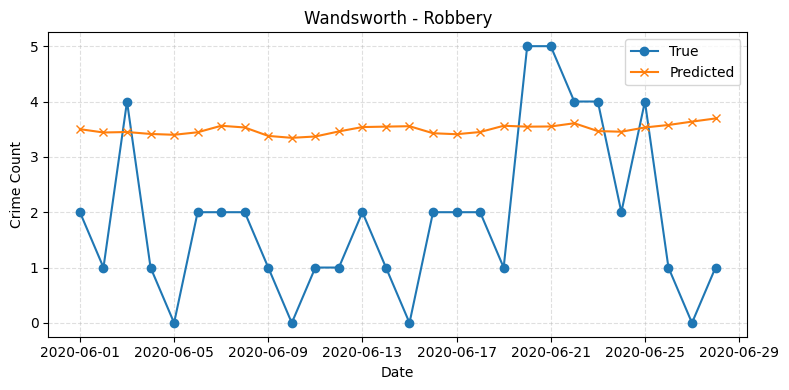

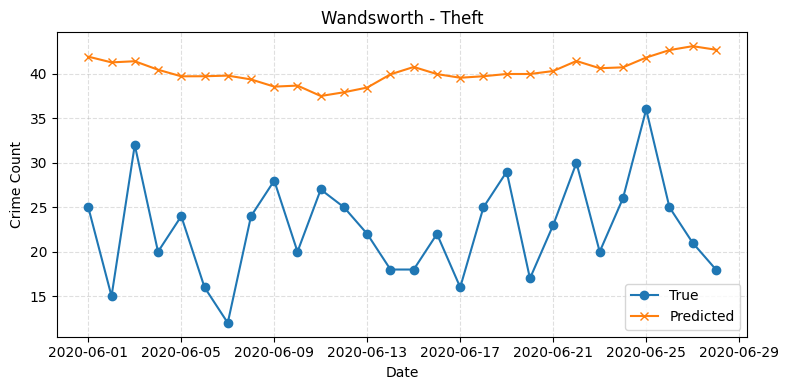

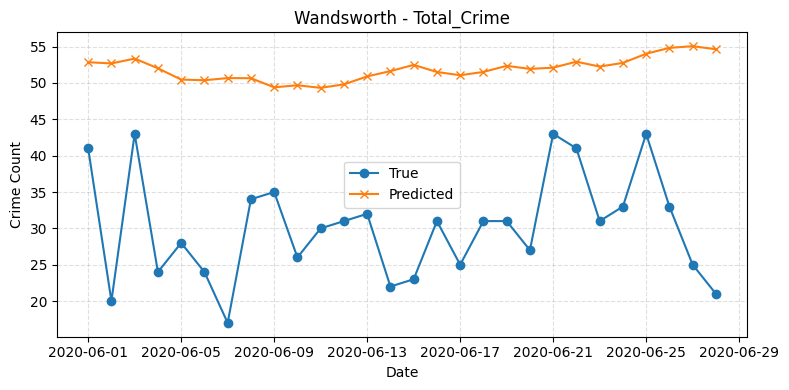

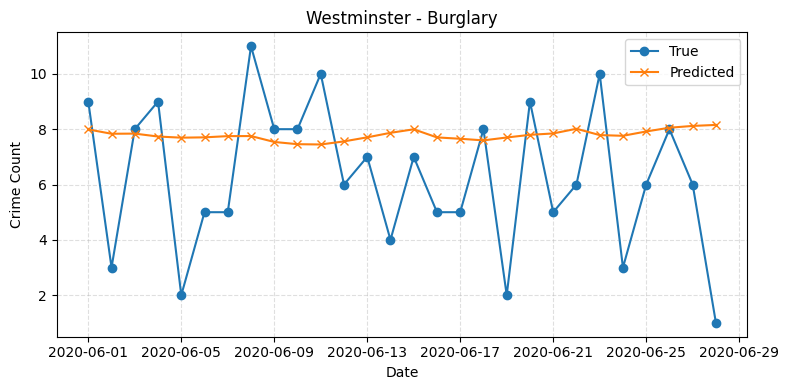

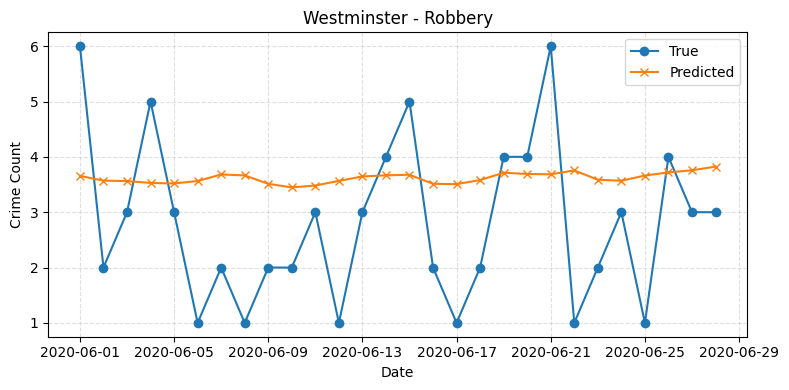

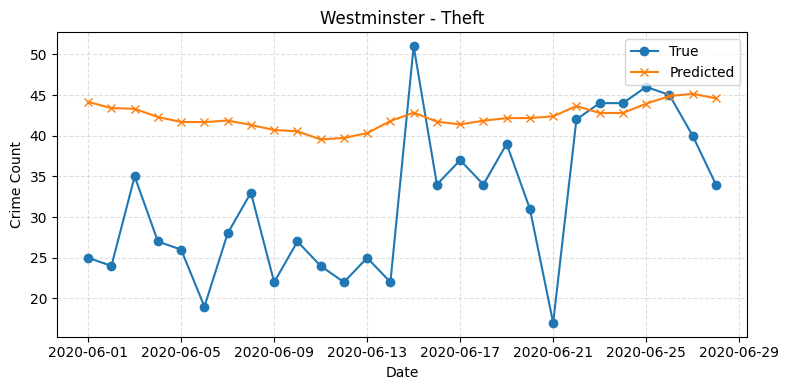

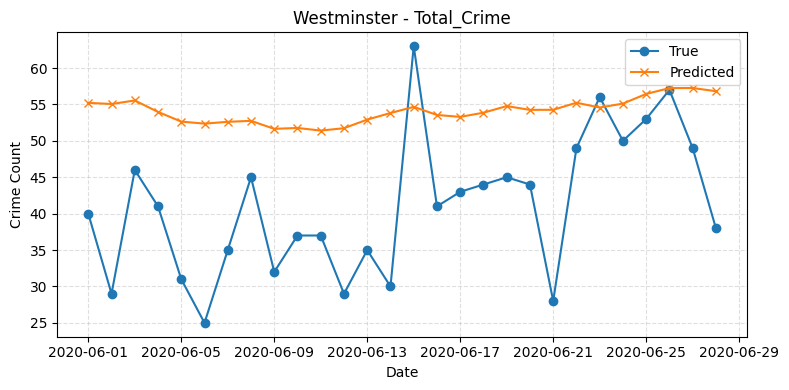

In [110]:
for borough in boroughs:
    preds = all_predictions[borough]["pred"]
    true  = all_predictions[borough]["true"]
    dates = all_predictions[borough]["dates"]

    for j, crime in enumerate(targets):  
        plt.figure(figsize=(8, 4))
        plt.plot(dates, true[:, j], label="True", marker="o")
        plt.plot(dates, preds[:, j], label="Predicted", marker="x")
        plt.title(f"{borough} - {crime}")
        plt.xlabel("Date")
        plt.ylabel("Crime Count")
        plt.grid(True, linestyle="--", alpha=0.4)
        plt.legend()
        plt.tight_layout()
        plt.show()

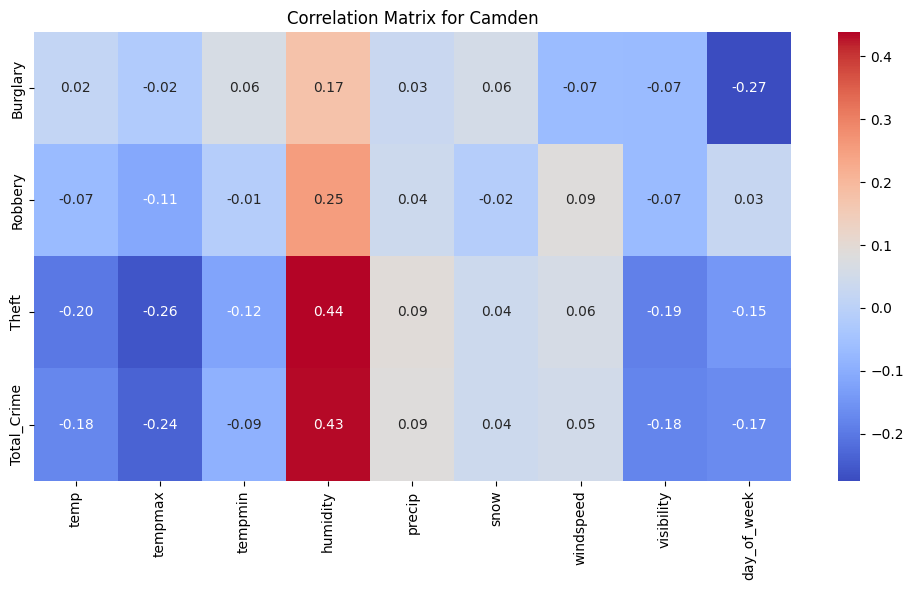

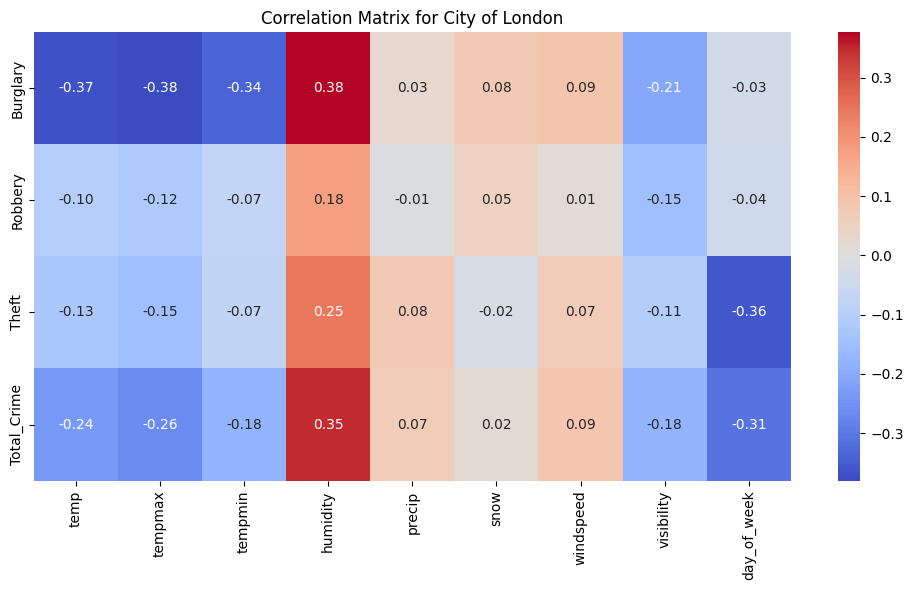

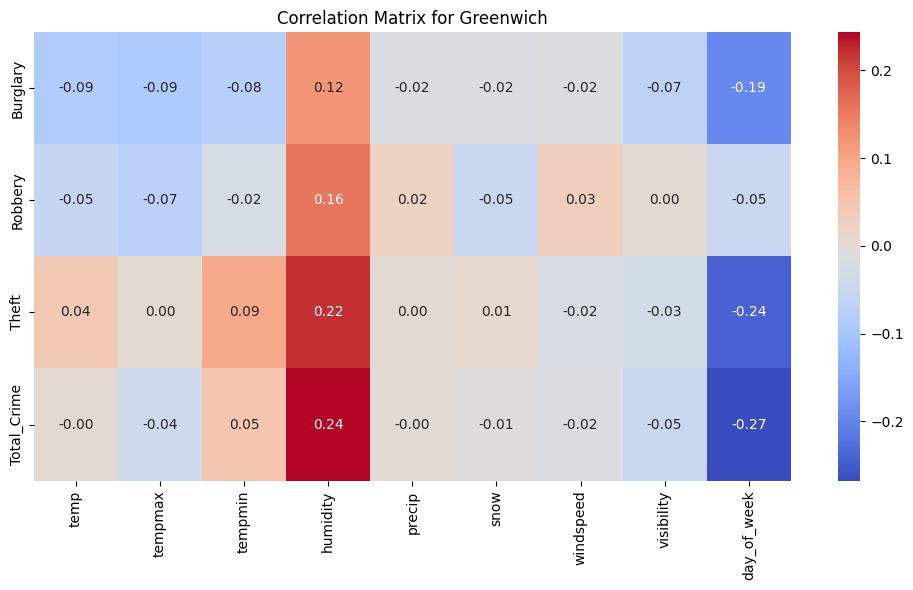

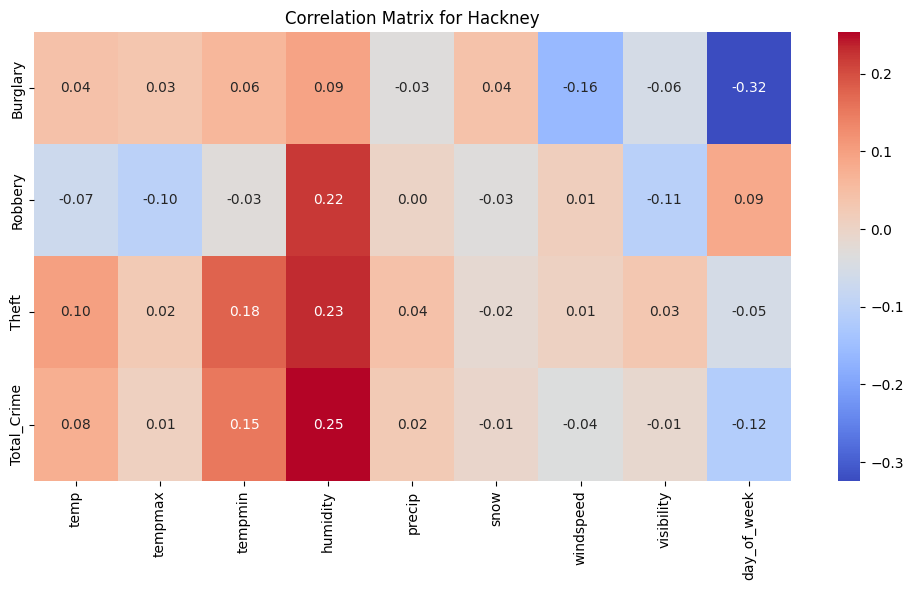

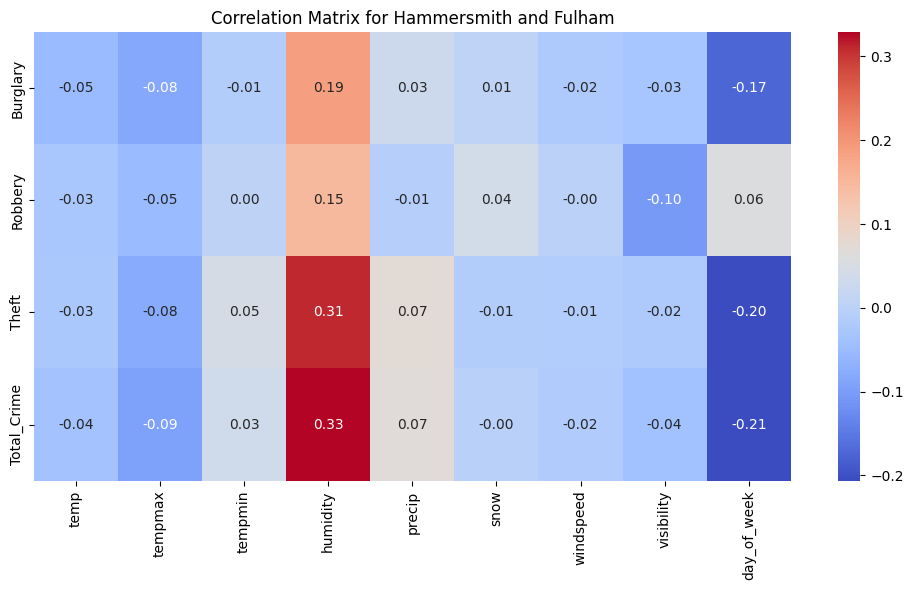

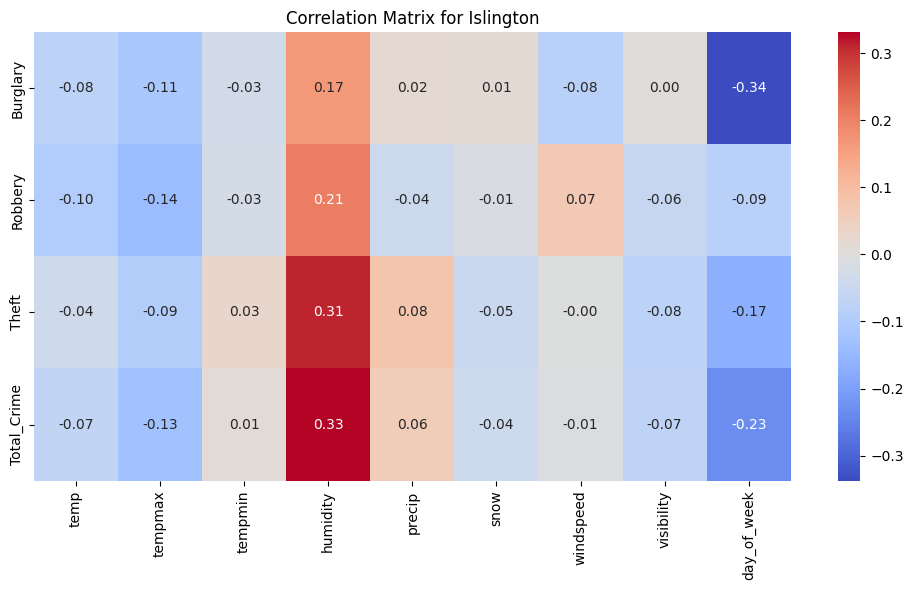

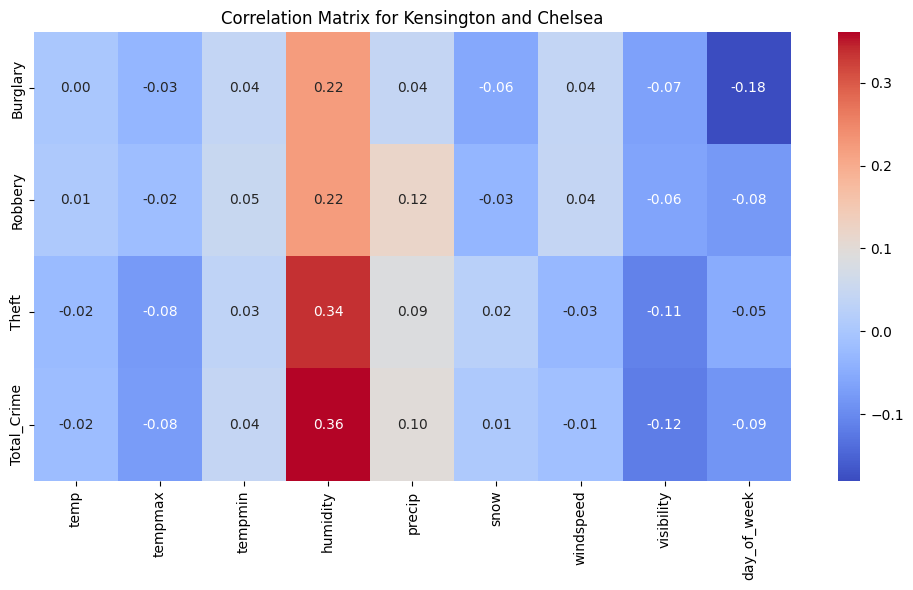

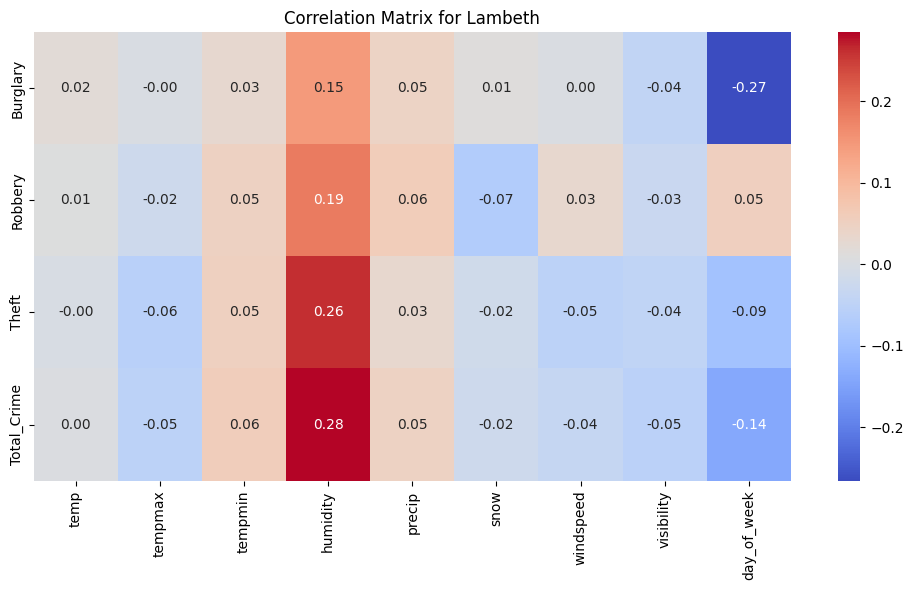

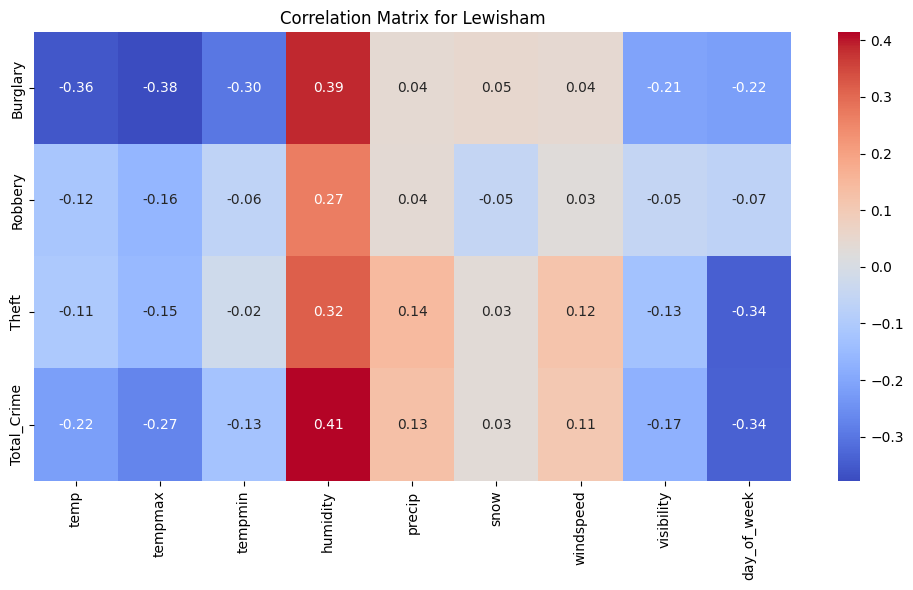

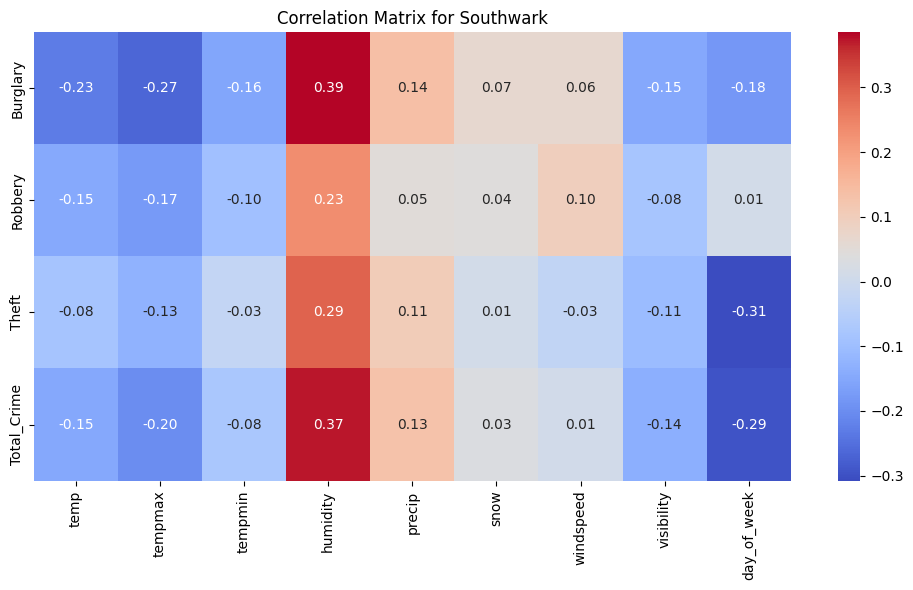

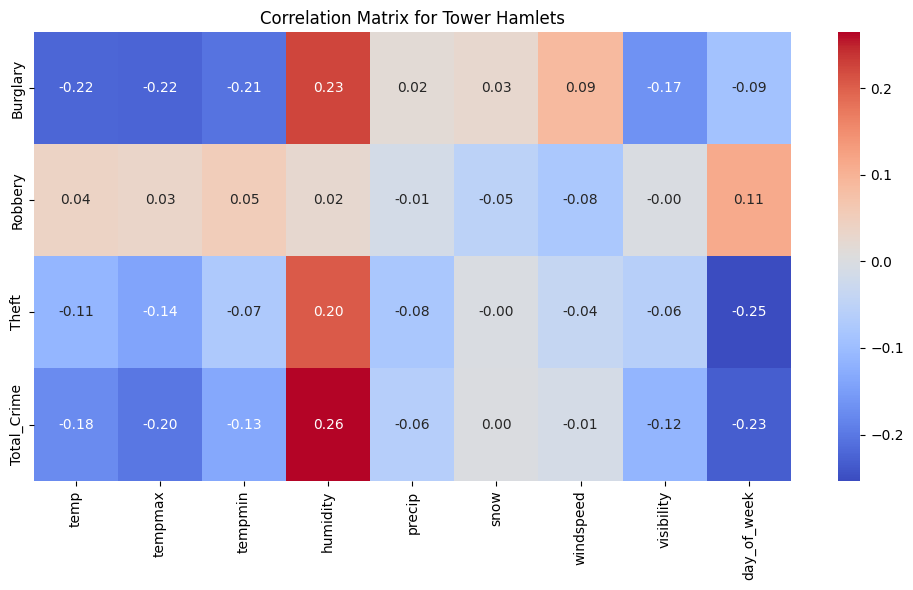

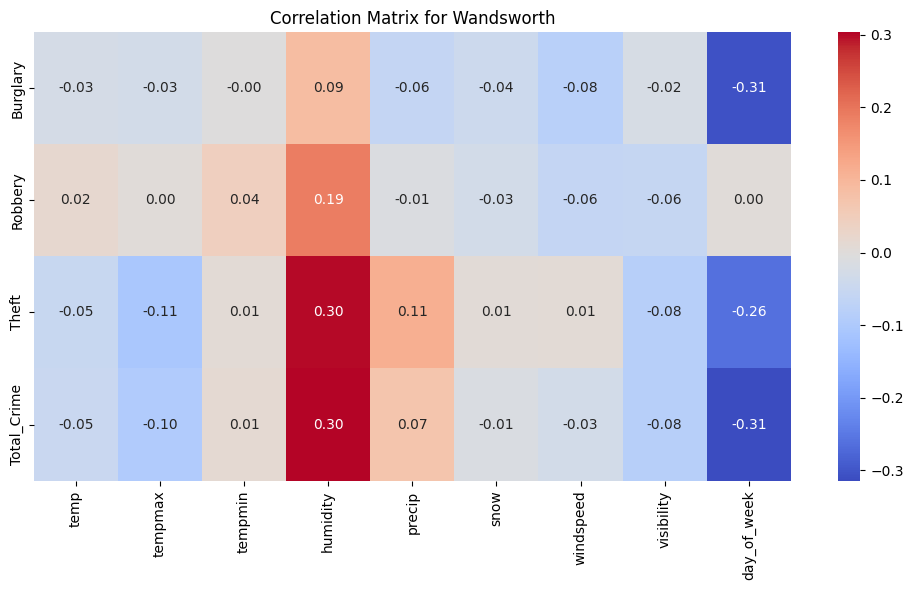

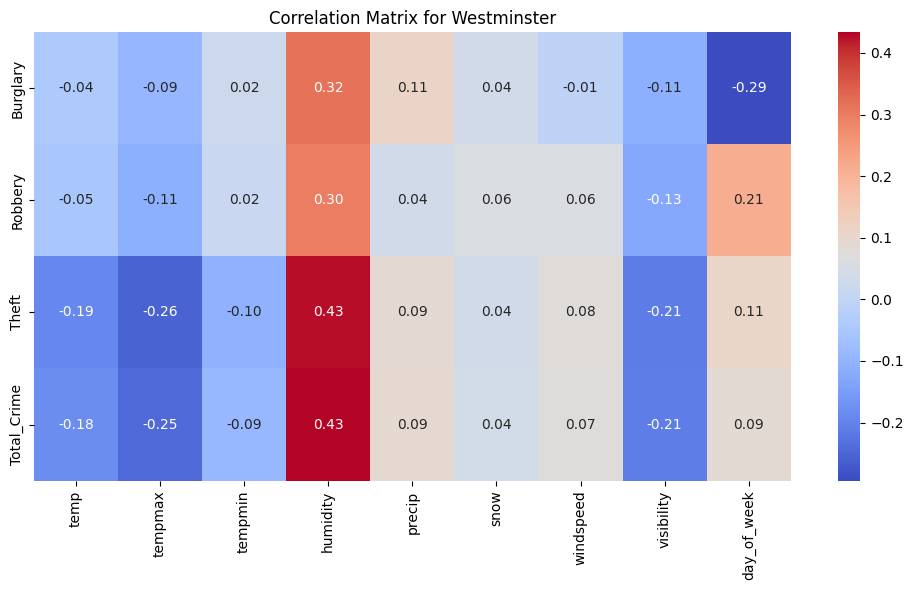

,Borough,Crime,temp,tempmax,tempmin,humidity,precip,snow,windspeed,visibility,day_of_week
0,Camden,Burglary,0.017523,-0.021565,0.063255,0.174866,0.029364,0.055039,-0.067621,-0.068513,-0.274402
1,Camden,Robbery,-0.070081,-0.112691,-0.013170,0.252550,0.039213,-0.015171,0.086494,-0.069807,0.026174
2,Camden,Theft,-0.201416,-0.258560,-0.119096,0.438176,0.091335,0.038086,0.060392,-0.185982,-0.145948
3,Camden,Total_Crime,-0.176438,-0.236838,-0.091791,0.432644,0.087332,0.039953,0.050124,-0.178111,-0.167906
4,City of London,Burglary,-0.370789,-0.379852,-0.336650,0.376233,0.025159,0.078135,0.090685,-0.206316,-0.034903
5,City of London,Robbery,-0.100308,-0.119504,-0.070128,0.175535,-0.005064,0.048948,0.011166,-0.149553,-0.042898
6,City of London,Theft,-0.125848,-0.151920,-0.074234,0.245953,0.078265,-0.021412,0.069939,-0.106852,-0.360562
7,City of London,Total_Crime,-0.237542,-0.264828,-0.179726,0.349318,0.070219,0.016326,0.087301,-0.178358,-0.309276
8,Greenwich,Burglary,-0.086762,-0.090358,-0.076461,0.121355,-0.018960,-0.018646,-0.015882,-0.066317,-0.194408
9,Greenwich,Robbery,-0.054020,-0.073744,-0.024909,0.156953,0.024516,-0.048761,0.029889,0.000374,-0.049667


In [113]:
# Define relevant features and crime targets
base_features = ["temp", "tempmax", "tempmin", "humidity", "precip", "snow", "windspeed", "visibility", "day_of_week"]
crime_types = ["Burglary", "Robbery", "Theft", "Total_Crime"]

# Container for correlation summary
correlation_summary = []

# Loop through each borough
for borough in df["Borough"].unique():
    borough_df = df[df["Borough"] == borough]

    # Compute correlation matrix
    corr_matrix = borough_df[base_features + crime_types].corr()

    # Plot heatmap 
    plt.figure(figsize=(10, 6))
    sns.heatmap(corr_matrix.loc[crime_types, base_features], annot=True, cmap="coolwarm", fmt=".2f")
    plt.title(f"Correlation Matrix for {borough}")
    plt.tight_layout()
    plt.show()

    # Extract correlation values for summary table
    for crime in crime_types:
        row = {"Borough": borough, "Crime": crime}
        for feature in base_features:
            row[feature] = corr_matrix.loc[crime, feature]
        correlation_summary.append(row)

# Create and display summary DataFrame
correlation_df = pd.DataFrame(correlation_summary)
correlation_df